One of the ways to build a robust robotics pipeline for general purpose manipulation, is by a building a modular stack of perception planning and control. This is also more interpretable and easy to debug which is particularly important for real-world deployment.

In this notebook, we start to build this concept from the foundations.

# Open-Vocabulary Table-Top Pick and Place Manipulation

Our current focus is on simple table-top pick and place general-purpose manipulation. To this end, we define a **KUKA robot** in a Pybullet simulation environment with a goal of being able to do pick and place of arbitrary objects zero-shot. We use everyday objects as obtained from the **Google Scanned Objects** project and **OWL-ViT** (short for Vision Transformer for Open-World Localization) for object detection.

## Helpers

In [ ]:
# Install packages
!pip install pybullet imageio-ffmpeg # (building wheels for pybullet may take a lot of time!)

In [ ]:
!pip install -q transformers==4.41.2
!pip install Pillow matplotlib opencv-python groq openai moviepy

In [ ]:
import os
import time
import math
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import imageio_ffmpeg
from base64 import b64encode
from IPython.display import HTML
from typing import List, Dict, Tuple, Any, Optional
from heapq import nlargest
import json

import pybullet as p
import pybullet_data

import torch
from transformers import Owlv2Processor, Owlv2ForObjectDetection

In [ ]:
# Helpers

def play_video(path):
  mp4 = open(path, 'rb').read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
  return HTML('<video width=480 controls><source src="%s" type="video/mp4"></video>' % data_url)

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Environment Setup

In [ ]:
"""
TableTopEnv Class - FIXED VERSION
Key fixes:
1. z_offset_grab = 0.32 (not 0.1!) for proper grasp height
2. np.ascontiguousarray() for video recording
3. Proper camera views (side_view=True for 3rd person)
4. Dynamic grasp height based on object dimensions
"""

class TableTopEnv:
    def __init__(self, config=None):
        self.gui = False
        self.client_id = None

        # IDs
        self.plane_id = None
        self.table_id = None
        self.kuka_id = None
        self.gripper_id = None
        self.object_ids = {}
        self.initial_objects_config = {}

        # Robot constants
        self.ee_idx = 6
        self.num_joints = None

        # Camera
        self.cam_params = {}

        # Workspace bounds
        self.workspace = {
            "x": (0.55, 1.08),
            "y": (-0.83, 0.43),
            "z": (0.65, 1.0),
        }

        # Define corners and middle
        xmin, xmax = self.workspace["x"]
        ymin, ymax = self.workspace["y"]
        z = self.workspace["z"][0]
        self.special_pts = {
            "tlc": [xmin + 0.05, ymax - 0.05, z],
            "trc": [xmax - 0.05, ymax - 0.05, z],
            "blc": [xmin + 0.05, ymin + 0.05, z],
            "brc": [xmax - 0.05, ymin + 0.05, z],
            "mid": [(xmin + xmax) / 2, (ymin + ymax) / 2, z],
            "top left corner": [xmin + 0.05, ymax - 0.05, z],
            "top right corner": [xmax - 0.05, ymax - 0.05, z],
            "bottom left corner": [xmin + 0.05, ymin + 0.05, z],
            "bottom right corner": [xmax - 0.05, ymin + 0.05, z],
            "middle": [(xmin + xmax) / 2, (ymin + ymax) / 2, z],
        }

    def reset(self, object_dict, retracted_arm=False, side_view=False, use_gso=False):
        print(f"  [ENV RESET] retracted_arm={retracted_arm}, side_view={side_view}")
        self._connect()
        self._load_scene()
        self._load_robot(retracted_arm=retracted_arm)
        self._setup_camera(side_view=side_view)
        self.load_objects(object_dict, use_gso=use_gso)
        for _ in range(100):
            p.stepSimulation()

        # Debug: Print initial robot state
        ee_state = p.getLinkState(self.kuka_id, self.ee_idx)
        print(f"  [ENV RESET] Initial EE position: [{ee_state[4][0]:.3f}, {ee_state[4][1]:.3f}, {ee_state[4][2]:.3f}]")
        print(f"  [ENV RESET] Initial EE orientation (quat): {[f'{x:.3f}' for x in ee_state[5]]}")

        # Convert quaternion to euler for readability
        euler = p.getEulerFromQuaternion(ee_state[5])
        print(f"  [ENV RESET] Initial EE orientation (euler deg): [{math.degrees(euler[0]):.1f}, {math.degrees(euler[1]):.1f}, {math.degrees(euler[2]):.1f}]")

    def _connect(self):
        if p.isConnected():
            p.disconnect()
        mode = p.GUI if self.gui else p.DIRECT
        self.client_id = p.connect(mode)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -10)
        p.setTimeStep(1./240.)

    def close(self):
        if self.client_id is not None:
            p.disconnect(self.client_id)
            self.client_id = None

    def _load_scene(self):
        self.plane_id = p.loadURDF("plane.urdf")
        self.table_id = p.loadURDF(
            "table/table.urdf",
            basePosition=[1.0, -0.2, 0.0],
            baseOrientation=[0, 0, 0.7071, 0.7071]
        )

    def _load_robot(self, retracted_arm=False):
        self.kuka_id = p.loadURDF(
            "kuka_iiwa/model_vr_limits.urdf",
            basePosition=[1.4, -0.2, 0.6],
            baseOrientation=[0, 0, 0, 1]
        )
        self.gripper_id = p.loadSDF(
            "gripper/wsg50_one_motor_gripper_new_free_base.sdf"
        )[0]
        self._attach_gripper()
        self._reset_robot(retracted_arm=retracted_arm)
        self.num_joints = p.getNumJoints(self.kuka_id)

    def _attach_gripper(self):
        p.createConstraint(
            self.kuka_id, 6, self.gripper_id, 0, p.JOINT_FIXED,
            [0, 0, 0], [0, 0, 0.05], [0, 0, 0]
        )
        cid = p.createConstraint(
            self.gripper_id, 4, self.gripper_id, 6,
            jointType=p.JOINT_GEAR, jointAxis=[1, 1, 1],
            parentFramePosition=[0, 0, 0], childFramePosition=[0, 0, 0]
        )
        p.changeConstraint(cid, gearRatio=-1, erp=0.5, relativePositionTarget=0, maxForce=100)

    def _reset_robot(self, retracted_arm=False):
        print(f"    [_reset_robot] retracted_arm={retracted_arm}")
        if retracted_arm:
            kuka_joints = [0.0, 0.0, 0.0, -0.5, 0.0, 1.0, 0.0]
            gripper_base_pos = [1.2, -0.2, 1.5]
            gripper_base_orn = p.getQuaternionFromEuler([0, math.pi/2, 0])
            print(f"    [_reset_robot] Using RETRACTED configuration (gripper UP)")
        else:
            kuka_joints = [0.0, 0.75, 0.0, 1.570793, 0.0, -1.036725, 0.0]
            gripper_base_pos = [0.923103, -0.2, 1.250036]
            gripper_base_orn = [-0.0, 0.964531, -0.0, -0.263970]
            print(f"    [_reset_robot] Using NORMAL configuration (gripper DOWN)")

        print(f"    [_reset_robot] kuka_joints: {kuka_joints}")
        print(f"    [_reset_robot] gripper_base_pos: {gripper_base_pos}")
        print(f"    [_reset_robot] gripper_base_orn: {gripper_base_orn}")

        for j in range(p.getNumJoints(self.kuka_id)):
            p.resetJointState(self.kuka_id, j, kuka_joints[j])
            p.setJointMotorControl2(self.kuka_id, j, p.POSITION_CONTROL, kuka_joints[j], 0)

        p.resetBasePositionAndOrientation(self.gripper_id, gripper_base_pos, gripper_base_orn)

        gripper_joints = [0.0, -0.011130, -0.206421, 0.205143, -0.009999, 0.0, -0.010055, 0.0]
        for j in range(p.getNumJoints(self.gripper_id)):
            p.resetJointState(self.gripper_id, j, gripper_joints[j])
            p.setJointMotorControl2(self.gripper_id, j, p.POSITION_CONTROL, gripper_joints[j], 0)

    def load_objects(self, object_dict, use_gso=False):
        self.initial_objects_config = object_dict.copy()
        if use_gso:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=True)
            p.setAdditionalSearchPath('/content/drive/MyDrive/GSO')

        for name, cfg in object_dict.items():
            obj_id = p.loadURDF(
                cfg["path"],
                basePosition=cfg["position"],
                globalScaling=cfg.get("scale", 1.0)
            )
            self.object_ids[name] = obj_id

    def _setup_camera(self, side_view=False):
        """Setup camera. side_view=True gives 3rd person corner view (RECOMMENDED)."""
        if side_view:  # 3rd person corner view - BETTER FOR VISUALIZATION
            self.cam_params = dict(
                target=[0.85, -0.2, 0.65], distance=1.5, yaw=45, pitch=-35, roll=0,
                up_axis=2, up_vector=[0, 0, 1], width=480, height=480, fov=60, near=0.01, far=100
            )
        else:  # Top-down view - needed for detection
            self.cam_params = dict(
                target=[0.85, -0.2, 0.65], distance=1.5, yaw=0, pitch=-90, roll=0,
                up_axis=2, up_vector=[0, 0, 1], width=480, height=480, fov=60, near=0.01, far=100
            )

    def set_camera_view(self, side_view=True):
        """Switch camera view dynamically."""
        self._setup_camera(side_view=side_view)

    def render(self):
        c = self.cam_params
        view = p.computeViewMatrixFromYawPitchRoll(c["target"], c["distance"], c["yaw"], c["pitch"], c["roll"], 2)
        proj = p.computeProjectionMatrixFOV(c["fov"], c["width"] / c["height"], c["near"], c["far"])
        img = p.getCameraImage(c["width"], c["height"], view, proj)[2][:, :, :3]
        return img

    def is_within_bounds(self, pos, margin=0.02):
        if pos is None:
            return False
        x, y, _ = pos
        return (
            (self.workspace["x"][0] + margin <= x <= self.workspace["x"][1] - margin) and
            (self.workspace["y"][0] + margin <= y <= self.workspace["y"][1] - margin)
        )

    def pixel_to_world(self, px, py):
        c = self.cam_params
        px = np.clip(px, 0, c["width"] - 1)
        py = np.clip(py, 0, c["height"] - 1)

        view = p.computeViewMatrixFromYawPitchRoll(c["target"], c["distance"], c["yaw"], c["pitch"], c["roll"], c["up_axis"])
        proj = p.computeProjectionMatrixFOV(c["fov"], c["width"] / c["height"], c["near"], c["far"])

        view = np.array(view).reshape(4, 4).T
        proj = np.array(proj).reshape(4, 4).T

        try:
            inv_vp = np.linalg.inv(proj @ view)
        except np.linalg.LinAlgError:
            return None

        x_ndc = (2.0 * px) / c["width"] - 1.0
        y_ndc = 1.0 - (2.0 * py) / c["height"]

        near = np.array([x_ndc, y_ndc, -1.0, 1.0])
        far = np.array([x_ndc, y_ndc, 1.0, 1.0])

        near_w = inv_vp @ near
        far_w = inv_vp @ far

        if abs(near_w[3]) < 1e-8 or abs(far_w[3]) < 1e-8:
            return None

        near_w /= near_w[3]
        far_w /= far_w[3]

        ray_dir = far_w[:3] - near_w[:3]
        ray_norm = np.linalg.norm(ray_dir)
        if ray_norm < 1e-8:
            return None
        ray_dir /= ray_norm

        ray_origin = near_w[:3]
        z_plane = self.workspace["z"][0]

        if abs(ray_dir[2]) < 1e-8:
            return None

        t = (z_plane - ray_origin[2]) / ray_dir[2]
        if t < 0:
            return None

        world = ray_origin + t * ray_dir
        world = world.tolist()
        return world if self.is_within_bounds(world) else None

    def move_ee(self, position, orientation=None):
        if orientation is None:
            orientation = p.getQuaternionFromEuler([0, 1.01 * math.pi, 0])
        joint_poses = p.calculateInverseKinematics(self.kuka_id, self.ee_idx, position, orientation)
        for j in range(p.getNumJoints(self.kuka_id)):
            p.setJointMotorControl2(self.kuka_id, j, p.POSITION_CONTROL, joint_poses[j])

    def _set_gripper(self, width, force=100):
        p.setJointMotorControl2(self.gripper_id, 4, p.POSITION_CONTROL, width, force=force)
        p.setJointMotorControl2(self.gripper_id, 6, p.POSITION_CONTROL, width, force=force)

    def open_gripper(self):
        self._set_gripper(-0.1, force=300)  # Negative value = wider spread
        for _ in range(150):  # More steps to fully open
            p.stepSimulation()

    def close_gripper(self):
        self._set_gripper(0.15, force=200)  # 0.15 = fingers together (CLOSED)
        for _ in range(100):
            p.stepSimulation()

    def start_video(self, path="vid.mp4", fps=30):
        c = self.cam_params
        self._video = imageio_ffmpeg.write_frames(path, (c["width"], c["height"]), fps=fps)
        self._video.send(None)

    def record_frame(self, image):
        """Record frame - FIXED with np.ascontiguousarray to prevent C-contiguous error."""
        if hasattr(self, "_video"):
            self._video.send(np.ascontiguousarray(image))

    def stop_video(self):
        if hasattr(self, "_video"):
            self._video.close()
            del self._video

    def _move_and_step(self, target_pos, gripper_open, steps=200, record_every=8):
        self.move_ee(target_pos)
        if gripper_open:
            self.open_gripper()
        else:
            self.close_gripper()

        record_every = 1 if steps < record_every else record_every
        for i in range(steps):
            p.stepSimulation()
            if hasattr(self, "_video") and i % record_every == 0:
                self.record_frame(self.render())

    def _move_and_step_slow(self, target_pos, gripper_open, steps=100, record_every=8, debug_label=""):
        current_pos = np.array(p.getLinkState(self.kuka_id, self.ee_idx)[4])
        target_pos = np.array(target_pos)

        if debug_label:
            print(f"    [DEBUG] {debug_label}")
            print(f"      Current EE pos: [{current_pos[0]:.3f}, {current_pos[1]:.3f}, {current_pos[2]:.3f}]")
            print(f"      Target pos: [{target_pos[0]:.3f}, {target_pos[1]:.3f}, {target_pos[2]:.3f}]")
            print(f"      Gripper command: {'OPEN' if gripper_open else 'CLOSED'}")
            gripper_joint_state = p.getJointState(self.gripper_id, 4)
            print(f"      Gripper joint position BEFORE: {gripper_joint_state[0]:.4f}")

        if gripper_open:
            self.open_gripper()
        else:
            self.close_gripper()

        record_every = 1 if steps < record_every else record_every
        for i in range(steps):
            fraction = (i + 1) / steps
            intermediate_pos = current_pos + (target_pos - current_pos) * fraction
            self.move_ee(intermediate_pos)
            p.stepSimulation()
            if hasattr(self, "_video") and i % record_every == 0:
                self.record_frame(self.render())

        if debug_label:
            final_pos = np.array(p.getLinkState(self.kuka_id, self.ee_idx)[4])
            print(f"      Final EE pos: [{final_pos[0]:.3f}, {final_pos[1]:.3f}, {final_pos[2]:.3f}]")
            gripper_joint_state = p.getJointState(self.gripper_id, 4)
            print(f"      Gripper joint position AFTER: {gripper_joint_state[0]:.4f}")
            error = np.linalg.norm(final_pos - target_pos)
            if error > 0.05:
                print(f"      WARNING: Position error = {error:.3f} (>0.05)")

    def execute_pick_and_place(self, src_xyz, tgt_xyz, z_offset_grab=0.32, record_video=False, video_path="vid.mp4"):
        """
        Classical pick-and-place with fixed top-down grasp.
        z_offset_grab = 0.32 is CRITICAL - must be high enough to clear tall objects!
        """
        print(f"\n  [EXECUTE_PICK_AND_PLACE DEBUG]")
        print(f"    Source (pick): [{src_xyz[0]:.3f}, {src_xyz[1]:.3f}, {src_xyz[2]:.3f}]")
        print(f"    Target (place): [{tgt_xyz[0]:.3f}, {tgt_xyz[1]:.3f}, {tgt_xyz[2]:.3f}]")
        print(f"    z_offset_grab: {z_offset_grab:.3f}")
        print(f"    record_video: {record_video}")

        ee_state = p.getLinkState(self.kuka_id, self.ee_idx)
        print(f"    Initial EE position: [{ee_state[4][0]:.3f}, {ee_state[4][1]:.3f}, {ee_state[4][2]:.3f}]")
        print(f"    Initial EE orientation (quat): {[f'{x:.3f}' for x in ee_state[5]]}")

        print(f"    Workspace X: {self.workspace['x']}")
        print(f"    Workspace Y: {self.workspace['y']}")
        print(f"    Workspace Z: {self.workspace['z']}")

        pick_above = [src_xyz[0], src_xyz[1], src_xyz[2] + z_offset_grab + 0.2]
        pick_grasp = [src_xyz[0], src_xyz[1], src_xyz[2] + z_offset_grab]
        place_above = [tgt_xyz[0], tgt_xyz[1], src_xyz[2] + z_offset_grab + 0.2]
        place_release = [tgt_xyz[0], tgt_xyz[1], src_xyz[2] + z_offset_grab]

        print(f"    Planned trajectory:")
        print(f"      1. Pick above: {[f'{x:.3f}' for x in pick_above]}")
        print(f"      2. Pick grasp: {[f'{x:.3f}' for x in pick_grasp]}")
        print(f"      3. Pick lift:  {[f'{x:.3f}' for x in pick_above]}")
        print(f"      4. Place above: {[f'{x:.3f}' for x in place_above]}")
        print(f"      5. Place lower: {[f'{x:.3f}' for x in place_release]}")
        print(f"      6. Place retract: {[f'{x:.3f}' for x in place_above]}")

        if record_video:
            self.start_video(video_path)
            print(f"    Video recording started: {video_path}")

        print(f"\n  === PHASE 1: Move above pick location ===")
        self._move_and_step_slow(pick_above, gripper_open=True, steps=300, debug_label="Move above object")

        print(f"\n  === PHASE 2: Lower to grasp ===")
        self._move_and_step_slow(pick_grasp, gripper_open=True, steps=250, debug_label="Lower to grasp")

        print(f"\n  === PHASE 3: Close gripper ===")
        self._move_and_step_slow(pick_grasp, gripper_open=False, steps=300, debug_label="Close gripper")

        print(f"\n  === PHASE 4: Lift object ===")
        self._move_and_step_slow(pick_above, gripper_open=False, steps=300, debug_label="Lift object")

        print(f"\n  === PHASE 5: Transfer to place location ===")
        self._move_and_step_slow(place_above, gripper_open=False, steps=400, debug_label="Transfer")

        print(f"\n  === PHASE 6: Lower to place ===")
        self._move_and_step_slow(place_release, gripper_open=False, steps=250, debug_label="Lower to place")

        print(f"\n  === PHASE 7: Release object ===")
        self._move_and_step_slow(place_release, gripper_open=True, steps=300, debug_label="Release")

        print(f"\n  === PHASE 8: Retract ===")
        self._move_and_step_slow(place_above, gripper_open=True, steps=300, debug_label="Retract")

        if record_video:
            self.stop_video()
            print(f"    Video recording stopped")

        print(f"\n  [EXECUTE_PICK_AND_PLACE COMPLETE]")

    def generate_random_coordinates(self, n, min_distance=0.5, x_range=(0.6, 1.0), y_range=(-0.80, 0.40), z_fixed=0.65, max_retries_per_point=1000):
        if n <= 0:
            return np.array([])
        coordinates = []
        x_min, x_max = x_range
        y_min, y_max = y_range

        for point_idx in range(n):
            placed = False
            retries = 0
            while not placed and retries < max_retries_per_point:
                x = random.uniform(x_min, x_max)
                y = random.uniform(y_min, y_max)
                new_coord = [x, y, z_fixed]
                is_valid = True
                for existing_coord in coordinates:
                    if math.dist(new_coord, existing_coord) < min_distance:
                        is_valid = False
                        break
                if is_valid:
                    coordinates.append(new_coord)
                    placed = True
                else:
                    retries += 1
            if not placed:
                raise ValueError(f"Could not place all {n} points.")
        return np.array(coordinates)

    def generate_random_offset(self, base_magnitude=0.1, allow_negative=True):
        if allow_negative:
            x_sign = random.choice([-1, 1])
            y_sign = random.choice([-1, 1])
            x_offset = x_sign * random.uniform(base_magnitude, base_magnitude + 0.1)
            y_offset = y_sign * random.uniform(base_magnitude, base_magnitude + 0.1)
        else:
            x_offset = random.uniform(base_magnitude, base_magnitude + 0.1)
            y_offset = random.uniform(base_magnitude, base_magnitude + 0.1)
        return [x_offset, y_offset, 0.0]

    def get_object_dimensions(self, object_id):
        aabb = p.getAABB(object_id)
        min_coords = np.array(aabb[0])
        max_coords = np.array(aabb[1])
        dimensions = max_coords - min_coords
        return dimensions[0], dimensions[1], dimensions[2]

    def get_object_position(self, object_id):
        pos, _ = p.getBasePositionAndOrientation(object_id)
        return list(pos)

    def get_pybullet_id(self, object_name):
        for obj_key, obj_config in self.initial_objects_config.items():
            loaded_obj_name = obj_config["path"].split('/')[0]
            if object_name.lower() == loaded_obj_name.lower():
                if obj_key in self.object_ids:
                    return self.object_ids[obj_key]
        return None

    def get_object_world_position(self, object_name):
        obj_id = self.get_pybullet_id(object_name)
        if obj_id is not None:
            return self.get_object_position(obj_id)
        return None

    def get_safe_place_offset(self, pick_obj_id, place_obj_id=None, max_attempts=50):
        width1, length1, _ = self.get_object_dimensions(pick_obj_id)
        if place_obj_id is not None:
            width2, length2, _ = self.get_object_dimensions(place_obj_id)
            base_mag = (max(width1, length1) + max(width2, length2)) / 2 + 0.05
        else:
            base_mag = max(width1, length1) / 2 + 0.05

        for _ in range(max_attempts):
            offset = self.generate_random_offset(base_mag, allow_negative=True)
            yield offset
        yield [0.0, 0.0, 0.0]

In [ ]:
# Setup environment function

def setup_env(obj_names, retracted_arm=False, side_view=True):
    """
    Setup environment with specified objects.
    retracted_arm=False for normal operation (gripper pointing down)
    side_view=True gives 3rd person corner view (RECOMMENDED for videos)
    """
    env = TableTopEnv(config=None)
    n_objs = len(obj_names)

    # Use larger min_distance for more objects to prevent overlap
    # Also use z=0.70 to ensure objects spawn ABOVE table surface (0.65)
    # Adjust spacing and range based on number of objects
    if n_objs <= 2:
        min_dist = 0.35
        x_range = (0.65, 0.95)
        y_range = (-0.50, 0.25)
    elif n_objs <= 3:
        min_dist = 0.30
        x_range = (0.62, 0.98)
        y_range = (-0.55, 0.30)
    else:  # 4-5 objects
        min_dist = 0.25
        x_range = (0.60, 1.00)
        y_range = (-0.65, 0.35)

    generated_coords = env.generate_random_coordinates(
        n=n_objs,
        min_distance=min_dist,
        x_range=x_range,
        y_range=y_range,
        z_fixed=0.70  # Keep this above table surface
    )

    objects = {}
    for i, name in enumerate(obj_names):
        objects[f"obj{i+1}"] = {
            "path": f"{name}/{name}.urdf",
            "position": generated_coords[i],
            "scale": 1.0,
        }

    env.reset(objects, retracted_arm=retracted_arm, side_view=side_view, use_gso=True)
    return env, obj_names

Mounted at /content/drive


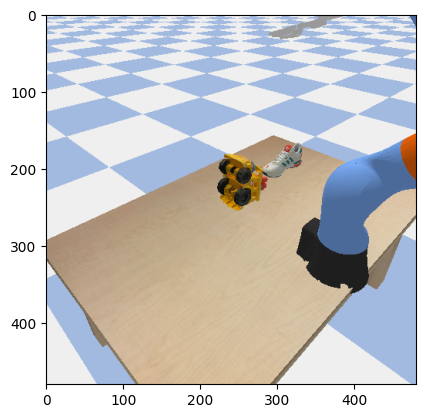

In [ ]:
# Test environment setup with visualization

obj_names_selected = ["Bus", "Shoe"]
env, obj_names_selected = setup_env(obj_names_selected, retracted_arm=False, side_view=True)

# Capture perception img
scene_image = env.render()
plt.imshow(Image.fromarray(scene_image))
plt.title("Scene with Bus and Shoe")
plt.axis('off')
plt.show()

# Test detector
env.set_camera_view(side_view=False)  # Switch to top-down for detection
detector = Detector(device=device, score_threshold=1e-4, env=env)

image = env.render()
text_queries = ["Bus", "Shoe"]
detections = detector.detect(image, text_queries)

for query in text_queries:
    best = detector.get_best_instance(detections, query)
    detector.plot(image, detections, best, plot_only_best=True)

    if best is not None:
        world_coord = best["world_coord"]
        print(f"World coordinates for '{query}': {world_coord}")
    else:
        print(f"No best instance found for '{query}'.")

env.set_camera_view(side_view=True)  # Switch back to side view

## Open-Vocabulary Object Detection

In [ ]:
"""
Detector Class for OWL-ViT object detection
"""

class Detector:
    def __init__(self, device="cpu", score_threshold=0.1, env=None):
        self.device = device
        self.score_threshold = score_threshold
        self.env = env

        self.processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16-ensemble")
        self.model = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16-ensemble")
        self.model = self.model.to(device)
        self.model.eval()

    def detect(self, image, text_queries):
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)

        inputs = self.processor(text=text_queries, images=image, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        target_sizes = torch.Tensor([image.size[::-1]]).to(self.device)
        results = self.processor.post_process_object_detection(
            outputs=outputs, target_sizes=target_sizes, threshold=self.score_threshold
        )[0]

        H, W = image.size[1], image.size[0]
        boxes_norm = []
        for box in results["boxes"]:
            x0, y0, x1, y1 = box.tolist()
            cx = (x0 + x1) / 2 / W
            cy = (y0 + y1) / 2 / H
            w = (x1 - x0) / W
            h = (y1 - y0) / H
            boxes_norm.append(np.array([cx, cy, w, h], dtype=np.float32))

        return {
            "scores": results["scores"].cpu().numpy().tolist(),
            "labels": results["labels"].cpu().numpy().tolist(),
            "boxes": boxes_norm,
            "text_queries": text_queries,
        }

    def get_best_instance(self, detections, query, min_confidence=None):
        threshold = min_confidence if min_confidence is not None else self.score_threshold
        best = None

        try:
            query_idx = detections["text_queries"].index(query)
        except ValueError:
            return None

        for score, box, label_idx in zip(detections["scores"], detections["boxes"], detections["labels"]):
            if score < threshold or label_idx != query_idx:
                continue

            cx, cy, w, h = box
            if w <= 0.01 or h <= 0.01 or w > 0.9 or h > 0.9:
                continue

            px = int(cx * self.env.cam_params["width"])
            py = int(cy * self.env.cam_params["height"])
            world_coord = self.env.pixel_to_world(px, py)

            if world_coord is None or not self.env.is_within_bounds(world_coord):
                continue

            if best is None or score > best["score"]:
                best = {
                    "score": float(score),
                    "box_norm": box.copy(),
                    "label": query,
                    "world_coord": world_coord,
                    "pixel_coord": (px, py)
                }

        return best

    def plot(self, image, detections, best=None, plot_only_best=True):
        H, W = image.shape[:2]
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(image)
        ax.axis("off")

        if not plot_only_best:
            for score, box, label_idx in zip(detections["scores"], detections["boxes"], detections["labels"]):
                if score < self.score_threshold:
                    continue
                cx, cy, w, h = box
                x0 = (cx - w / 2) * W
                x1 = (cx + w / 2) * W
                y0 = (cy - h / 2) * H
                y1 = (cy + h / 2) * H
                ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r", linewidth=1, alpha=0.5)

        if best is not None:
            cx, cy, w, h = best["box_norm"]
            x0 = (cx - w/2) * W
            x1 = (cx + w/2) * W
            y0 = (cy - h/2) * H
            y1 = (cy + h/2) * H
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "g", linewidth=2)
            ax.text(x0, y0 - 5, f"{best['label']} ({best['score']:.2f})", color="green", fontsize=10)

        plt.tight_layout()
        plt.show()
    
    def get_object_world_width(self, image, object_name):
        """
        Detects an object and calculates its width in world coordinates.
        """
        detections = self.detect(image, [object_name])
        best_instance = self.get_best_instance(detections, object_name)

        if not best_instance:
            print(f"Object '{object_name}' not found for width calculation.")
            return None

        box_norm = best_instance['box_norm']
        cx_norm, cy_norm, w_norm, h_norm = box_norm

        H, W = image.shape[:2]

        # Convert normalized coordinates to pixel coordinates
        x_center_px = cx_norm * W
        y_center_px = cy_norm * H
        width_px = w_norm * W

        x_min_px = int(x_center_px - width_px / 2)
        x_max_px = int(x_center_px + width_px / 2)
        y_center_px_int = int(y_center_px)

        # Convert pixel points to world coordinates
        left_world_coord = self.env.pixel_to_world(x_min_px, y_center_px_int)
        right_world_coord = self.env.pixel_to_world(x_max_px, y_center_px_int)

        if left_world_coord is None or right_world_coord is None:
            print(f"Could not convert pixel coordinates to valid world coordinates for '{object_name}'.")
            return None

        # Calculate Euclidean distance between the two world points
        world_width = np.linalg.norm(np.array(right_world_coord) - np.array(left_world_coord))
        return world_width

## Natural Language Instruction Parsing

Given any arbitrary user query for pick and place long-horizon tasks , we desire to parse it through an LLM to output list of pick and place motion primitives and execute them one by one. To this end, we use groq API and formatted output.

In [ ]:
"""
GroqCommandParser and SayCan Planning Components
"""
from google.colab import userdata
from groq import Groq
import openai

class GroqCommandParser:
    def __init__(self, api_key, model_id="llama-3.3-70b-versatile"):
        self.client = Groq(api_key=api_key)
        self.model_id = model_id

    def extract_commands(self, text):
        prompt = f"""You are a robot command parser. Extract pick and place commands.
Valid location codes: trc=top right corner, tlc=top left corner, brc=bottom right corner, blc=bottom left corner, mid=middle

Return JSON array with "pick" and "place" fields.
Example: Input: "Pick the Bus and place it on the Shoe" -> Output: [{{"pick": "Bus", "place": "Shoe"}}]

Input: "{text}"
Output:"""

        try:
            response = self.client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model=self.model_id, temperature=0.1, max_tokens=256
            )
            response_text = response.choices[0].message.content.strip()

            if "[" in response_text and "]" in response_text:
                json_str = response_text[response_text.index("["):response_text.rindex("]")+1]
                commands = json.loads(json_str)
                return [(cmd["pick"], cmd["place"]) for cmd in commands if "pick" in cmd and "place" in cmd]
            return []
        except Exception as e:
            print(f"Parser error: {e}")
            return []


class SayCanConfig:
    ENGINE = "davinci-002"
    TERMINATION_STRING = "done()"
    FIXED_LOCATIONS = ["top left corner", "top right corner", "bottom left corner", "bottom right corner", "middle"]

    RAW_CONTEXT = """objects = ["Bus", "Shoe"]
# put the bus on the shoe.
Pick the Bus and place it on the Shoe.
done()

objects = ["Bus", "Shoe"]
# move the shoe to the middle.
Pick the Shoe and place it on the middle.
done()
"""

    @staticmethod
    def get_processed_prompt(use_env_description=False):
        lines = SayCanConfig.RAW_CONTEXT.split("\n")
        return "\n".join([l for l in lines if "objects =" not in l or use_env_description])


class LLMClient:
    def __init__(self, api_key: str, engine: str = SayCanConfig.ENGINE):
        self.client = openai.OpenAI(api_key=api_key)
        self.engine = engine
        self.cache = {}
        self._call_count = 0

    def call(self, prompt, max_tokens=128, temperature=0, logprobs=1, echo=False):
        full_query = "".join(prompt) if isinstance(prompt, list) else prompt
        cache_id = (self.engine, full_query, max_tokens, temperature, logprobs, echo)
        if cache_id in self.cache:
            return self.cache[cache_id]

        self._call_count += 1
        print(f'API call #{self._call_count}')
        response = self.client.completions.create(model=self.engine, prompt=prompt, max_tokens=max_tokens,
                                                   temperature=temperature, logprobs=logprobs, echo=echo)
        self.cache[cache_id] = response
        return response

    def score_options(self, query: str, options: List[str], verbose=False):
        response = self.call(prompt=[query + opt for opt in options], max_tokens=0, logprobs=1, temperature=0, echo=True)
        scores = {}
        for option, choice in zip(options, response.choices):
            total = sum(lp for t, lp in zip(reversed(choice.logprobs.tokens), reversed(choice.logprobs.token_logprobs))
                       if t != "\n" and lp is not None)
            scores[option] = total
        return scores, response


class SceneManager:
    def __init__(self, detections, score_threshold=0.1):
        self.detections = detections
        self.score_threshold = score_threshold
        self.found_objects = list(set(
            detections["text_queries"][l] for s, l in zip(detections.get("scores", []), detections.get("labels", []))
            if s >= score_threshold and 0 <= l < len(detections["text_queries"])
        ))

    def get_found_objects(self): return self.found_objects
    def build_scene_description(self): return f"objects = {self.found_objects}"
    def is_object_present(self, name): return name.lower() in [o.lower() for o in self.found_objects]


class SayCanPlanner:
    def __init__(self):
        self.termination_string = SayCanConfig.TERMINATION_STRING

    def make_options(self, pick_targets, place_targets):
        options = [f"Pick the {pk} and place it on the {tg}." for pk in pick_targets for tg in place_targets if pk.lower() != tg.lower()]
        options.append(self.termination_string)
        print(f"Generated {len(options)} options")
        return options

    def calculate_affordance(self, options, found_objects, verbose=False):
        found_lower = [o.lower() for o in found_objects]
        all_targets = found_lower + [l.lower() for l in SayCanConfig.FIXED_LOCATIONS]
        if verbose:
            print(f"Found objects: {found_objects}")
            print(f"All possible targets: {all_targets}")

        scores = {}
        for opt in options:
            if opt == self.termination_string:
                scores[opt] = 0.2
                continue
            try:
                pick, place = opt.replace("Pick the ", "").replace(".", "").split(" and place it on the ")
                aff = 1.0 if (pick.lower() in found_lower and place.lower() in all_targets and pick.lower() != place.lower()) else 0.0
            except:
                aff = 0.0
            scores[opt] = aff
            if verbose and aff > 0:
                print(f"  {aff:.1f}\t{opt}")
        return scores

    def normalize_scores(self, scores):
        if not scores: return {}
        mx = max(scores.values())
        return {k: v/mx if mx > 0 else 0 for k, v in scores.items()}

    def select_best_action(self, scores, exclude_done=False):
        if exclude_done:
            scores = {k: v for k, v in scores.items() if k != self.termination_string}
        return max(scores, key=scores.get) if scores else self.termination_string

## Grounding the plan via affordances

While a long-horizon user instruction can be parsed into a formatted pick&place short-horizon primitives each mentioning the exact pick and place items/positions, naively executing this sequence may lead to failure. One must check the physical possibility (here, via affordances) of the primitive task before execution. Else, replan a correct one. This ensures the high-level task planning is grounded in its environment.

To this end, we take inspiration from SayCan and implement a scoring framework matching the LLMs plan with feasiblity as scored by an affordance model. For simplicity, in our pick and place centric framework, we simply use an object detector as an affordance proxy to validate the existance of pick and place items and locations. This score is multiplied with the LLMs score on various possible tasks to yield the final plan to be executed.

In [ ]:
# Visualization module for SayCan

class Visualizer:
    @staticmethod
    def plot_saycan(llm_scores, vfs, combined_scores, task, correct=True, show_top=None):
        if show_top:
            top_options = nlargest(show_top, combined_scores, key=combined_scores.get)
            top_llm_options = nlargest(show_top // 2, llm_scores, key=llm_scores.get)
            for llm_option in top_llm_options:
                if llm_option not in top_options:
                    top_options.append(llm_option)
            llm_scores = {option: llm_scores[option] for option in top_options}
            vfs = {option: vfs[option] for option in top_options}
            combined_scores = {option: combined_scores[option] for option in top_options}

        sorted_keys = dict(sorted(combined_scores.items()))
        keys = [key for key in sorted_keys]
        positions = np.arange(len(combined_scores.items()))
        width = 0.25

        fig, ax1 = plt.subplots(figsize=(14, 7))

        def norm(scores):
            mx = max(scores.values()) if scores else 1
            return {k: np.clip(scores[k]/mx, 0, 1) for k in scores}

        plot_llm_scores = norm({key: np.exp(llm_scores[key]) for key in sorted_keys})
        plot_llm_scores = np.asarray([plot_llm_scores[key] for key in sorted_keys])
        plot_affordance_scores = np.asarray([vfs[key] for key in sorted_keys])
        plot_combined_scores = np.asarray([combined_scores[key] for key in sorted_keys])

        ax1.bar(positions - width, plot_affordance_scores, width, alpha=0.8, color="#ea9999ff", label="affordance")
        ax1.bar(positions, plot_llm_scores, width, alpha=0.8, color="#a4c2f4ff", label="language")
        ax1.bar(positions + width, plot_combined_scores, width, alpha=0.8, color="#93CE8E", label="combined")

        ax1.set_xlabel("Options", fontsize=12, fontweight='bold')
        ax1.set_ylabel("Score (normalized)", fontsize=12, fontweight='bold')
        ax1.set_ylim(0.0, 1.05)
        ax1.set_xticks(positions)
        key_strings = [key.replace("Pick the ", "").replace(" and place it on the ", " → ").replace(".", "") for key in keys]
        ax1.set_xticklabels(key_strings, rotation=45, ha='right', fontsize=10)
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.legend(loc='upper right', fontsize=10)

        font = {"size": "14", "color": "k" if correct else "r", "weight": "bold"}
        ax1.set_title(task, **font)
        fig.tight_layout()
        plt.show()

## Execute and Play!

Mounted at /content/drive
Scene: objects = ['Bus', 'Shoe']
Considering 13 options
Scoring 13 options
-309.0265696869001 	 Pick the Shoe and place it on the Bus.
-309.84685784680005 	 done()
-311.25806478690004 	 Pick the Shoe and place it on the bottom right corner.
-312.0937401569 	 Pick the Shoe and place it on the top right corner.
-312.1302612869001 	 Pick the Shoe and place it on the bottom left corner.
-313.02294268690014 	 Pick the Shoe and place it on the Shoe.
-313.2363625869001 	 Pick the Shoe and place it on the middle.
-315.47458369820004 	 Pick the Bus and place it on the Shoe.
-317.80271216820006 	 Pick the Bus and place it on the Bus.
-318.60230364810013 	 Pick the Bus and place it on the bottom right corner.
-318.9045327481001 	 Pick the Bus and place it on the bottom left corner.
1 Selecting: Pick the Shoe and place it on the Bus.
Scoring 13 options
-308.4834637089001 	 done()
-316.6581335569001 	 Pick the Bus and place it on the Shoe.
-317.4327992292001 	 Pick the Sho

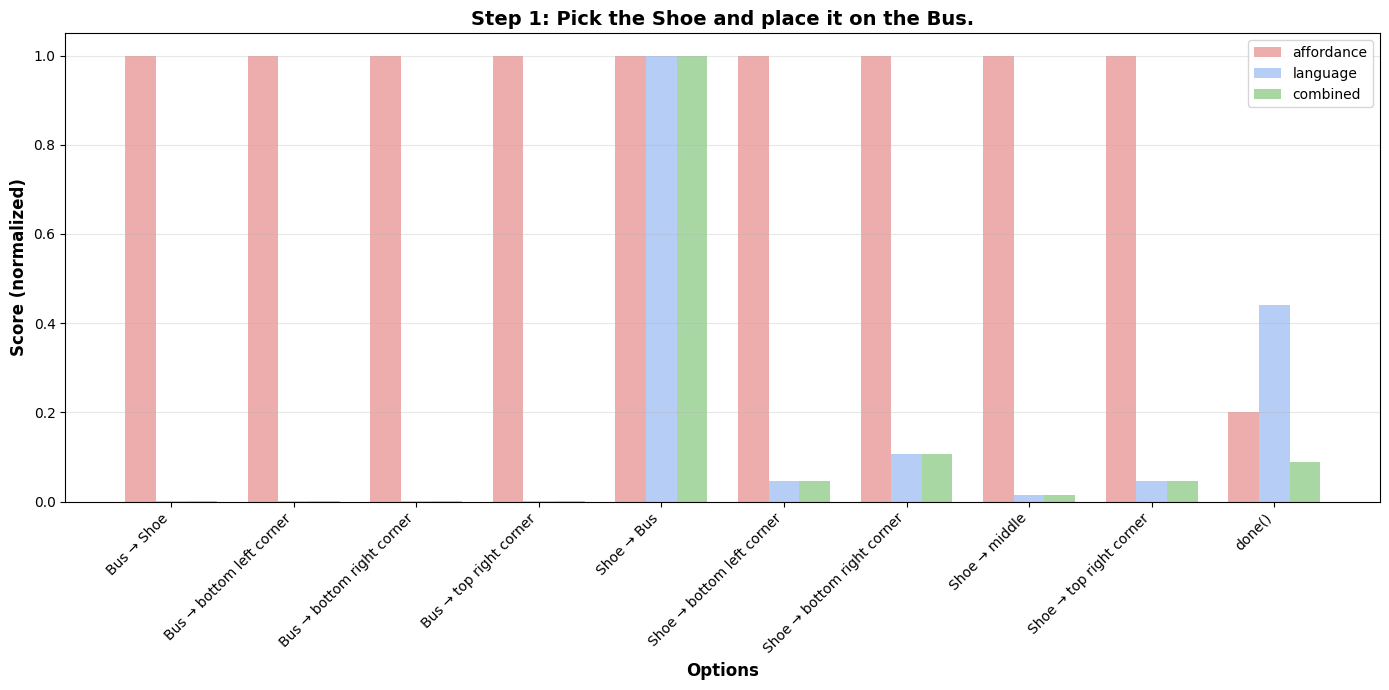

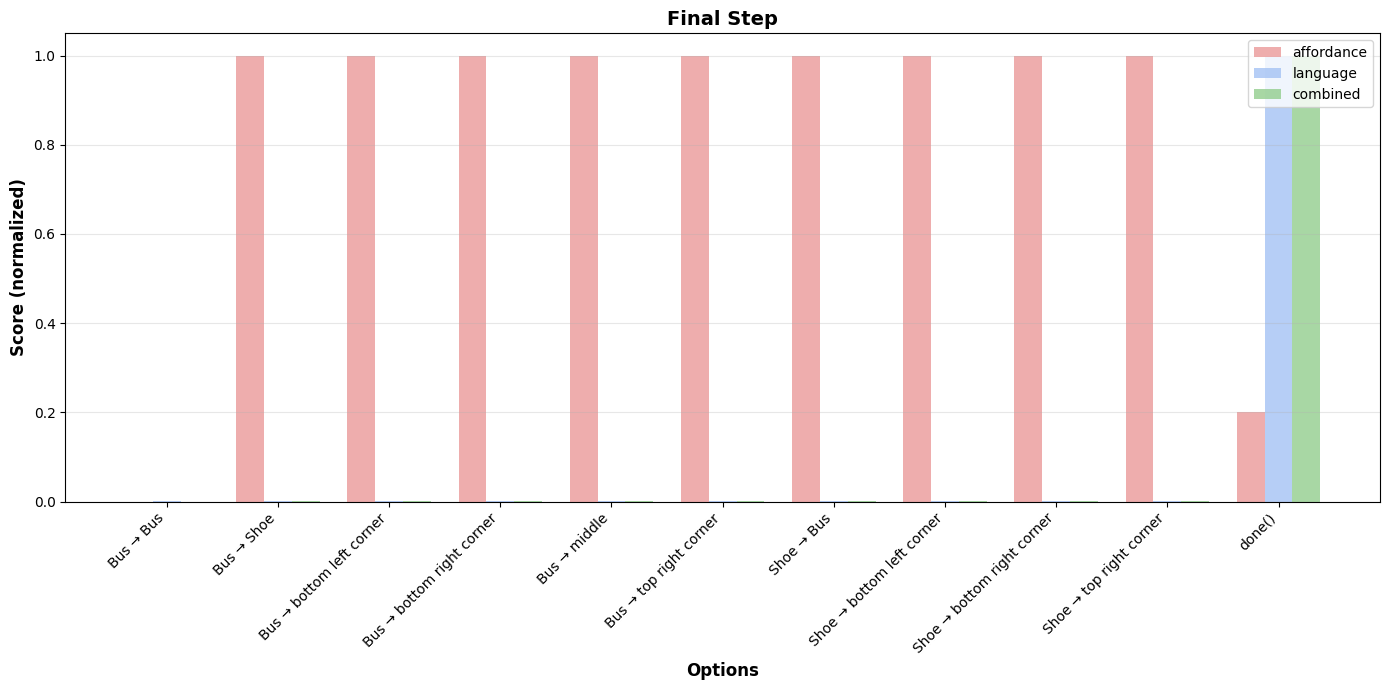


**** Solution ****
objects = ['Bus', 'Shoe']
# Pick the Shoe and place it near the Bus.
Step 1: Pick the Shoe and place it on the Bus.
Pick: ['Shoe']
Place: ['Bus']
--- Executing Step 1: Pick Shoe -> Place Bus ---
0.2632973553225208
0.18657095354246309
[np.float64(0.23793866943511993), np.float64(0.27787866846841597), 0.0]
[np.float64(0.23174445873733351), np.float64(0.23573048677301728), 0.0]
Stitching videos...
Moviepy - Building video full_mission.mp4.
Moviepy - Writing video full_mission.mp4



Moviepy - Done !
Moviepy - video ready full_mission.mp4


In [ ]:
"""
MAIN EXECUTION PIPELINE - FULLY FIXED
Fixes:
1. Uses PyBullet ground-truth positions (not detection)
2. z_offset_grab = 0.32 (proper grasp height)
3. side_view=True for 3rd person camera
4. np.ascontiguousarray for video recording
"""
from moviepy.editor import VideoFileClip, concatenate_videoclips
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning, module='moviepy')

# ============================================================================
#                         CONFIGURATION
# ============================================================================

obj_names_selected = ["Bus", "Shoe"]
raw_input = "Pick the shoe and place it in the middle. Then, pick up the bus and place it in the top right corner."
max_tasks = 5
plot_on = False  # Set True for SayCan visualization

# ============================================================================
#                        STEP 1: ENVIRONMENT SETUP
# ============================================================================

print("=" * 60)
print("STEP 1: Setting up environment")
print("=" * 60)

# retracted_arm=False for normal operation, side_view=True for 3rd person view
env, obj_names_selected = setup_env(obj_names_selected, retracted_arm=False, side_view=True)
print(f"Loaded {len(obj_names_selected)} objects: {obj_names_selected}")

print("\nGround-truth object positions (from PyBullet):")
for name in obj_names_selected:
    pos = env.get_object_world_position(name)
    if pos:
        print(f"  {name}: [{pos[0]:.3f}, {pos[1]:.3f}, {pos[2]:.3f}]")

# ============================================================================
#                        STEP 2: API INITIALIZATION
# ============================================================================

print("\n" + "=" * 60)
print("STEP 2: Initializing API clients")
print("=" * 60)

groq_api_key = userdata.get('GROQ_API_KEY')
openai_api_key = userdata.get('OPENAI_API_KEY')

parser = GroqCommandParser(api_key=groq_api_key)
llm = LLMClient(api_key=openai_api_key)
print("API clients initialized")

# ============================================================================
#                        STEP 3: PERCEPTION
# ============================================================================

print("\n" + "=" * 60)
print("STEP 3: Analyzing scene with object detection")
print("=" * 60)

# Switch to top-down view for detection (better accuracy)
env.set_camera_view(side_view=False)
detector = Detector(device=device, score_threshold=1e-4, env=env)
image = env.render()

text_queries = obj_names_selected.copy()
print(f"Detecting objects: {text_queries}")

detections = detector.detect(image, text_queries)
scene_manager = SceneManager(detections, score_threshold=1e-3)
detected_objects = scene_manager.get_found_objects()
print(f"Detected objects: {detected_objects}")

# IMPORTANT: Use ground truth for affordance (we know what objects we loaded!)
found_objects = obj_names_selected.copy()
print(f"Using ground truth for affordance: {found_objects}")

if set(detected_objects) != set(found_objects):
    missing = set(found_objects) - set(detected_objects)
    print(f"  NOTE: Detection missed {missing}, but we know they exist from PyBullet")

# Switch back to side view for execution and recording
env.set_camera_view(side_view=True)

# ============================================================================
#                        STEP 4: SAYCAN PLANNING
# ============================================================================

print("\n" + "=" * 60)
print("STEP 4: Planning with SayCan")
print("=" * 60)

planner = SayCanPlanner()
visualizer = Visualizer()

PICK_TARGETS = obj_names_selected
PLACE_TARGETS = obj_names_selected + SayCanConfig.FIXED_LOCATIONS

print(f"Scene: {scene_manager.build_scene_description()}")
options = planner.make_options(PICK_TARGETS, PLACE_TARGETS)

gpt3_prompt = SayCanConfig.get_processed_prompt() + "\n# " + raw_input + "\n"

steps_text = []
all_llm_scores = []
all_affordance_scores = []
all_combined_scores = []
affordance_scores = planner.calculate_affordance(options, found_objects, verbose=True)

num_tasks = 0
selected_task = ""
termination_string = SayCanConfig.TERMINATION_STRING

print(f"\nPlanning for: '{raw_input}'")
print("-" * 40)

while selected_task != termination_string and num_tasks < max_tasks:
    num_tasks += 1
    llm_scores, _ = llm.score_options(query=gpt3_prompt, options=options)
    combined_scores = planner.normalize_scores({opt: np.exp(llm_scores[opt]) * affordance_scores[opt] for opt in options})
    selected_task = max(combined_scores, key=combined_scores.get)

    # Skip if we already selected this exact task
    if selected_task in steps_text:
        print(f"  Step {num_tasks}: {selected_task} (DUPLICATE - skipping)")
        if selected_task in options:
            options.remove(selected_task)
            affordance_scores.pop(selected_task, None)
        continue

    steps_text.append(selected_task)
    all_llm_scores.append(llm_scores)
    all_affordance_scores.append(affordance_scores.copy())
    all_combined_scores.append(combined_scores)
    
    print(f"  Step {num_tasks}: {selected_task}")
    gpt3_prompt += selected_task + "\n"

# Optional: Visualize SayCan planning
if plot_on:
    for i, (l_scores, a_scores, c_scores, step) in enumerate(zip(
            all_llm_scores, all_affordance_scores, all_combined_scores, steps_text)):
        step_label = "Final Step" if step == termination_string else f"Step {i+1}: {step}"
        visualizer.plot_saycan(l_scores, a_scores, c_scores, step_label, show_top=10)

# ============================================================================
#                        STEP 5: COMMAND PARSING
# ============================================================================

print("\n" + "=" * 60)
print("STEP 5: Parsing planned actions into commands")
print("=" * 60)

# Remove duplicates while preserving order
unique_steps = []
for s in steps_text:
    if s and s != termination_string and s not in unique_steps:
        unique_steps.append(s)

print(f"Unique steps: {len(unique_steps)}")
for i, step in enumerate(unique_steps):
    print(f"  {i+1}. {step}")

# Parse each step individually with fallback
import re
commands = []
for step in unique_steps:
    print(f"\nParsing: {step}")
    step_commands = parser.extract_commands(step)
    if step_commands:
        commands.extend(step_commands)
        print(f"  -> Parsed: {step_commands}")
    else:
        # Fallback: manually extract from standard format
        match = re.match(r"Pick the (\w+) and place it on the (.+)\.", step)
        if match:
            pick_obj = match.group(1)
            place_loc = match.group(2)
            loc_map = {
                "top left corner": "tlc", "top right corner": "trc",
                "bottom left corner": "blc", "bottom right corner": "brc",
                "middle": "mid"
            }
            place_code = loc_map.get(place_loc.lower(), place_loc)
            commands.append((pick_obj, place_code))
            print(f"  -> Fallback parsed: ({pick_obj}, {place_code})")
        else:
            print(f"  -> FAILED to parse")

print(f"\nTotal parsed commands: {len(commands)}")

if not commands:
    print("ERROR: No commands parsed.")
    env.close()
    raise RuntimeError("Failed to parse commands")

pick = [cmd[0] for cmd in commands]
place = [cmd[1] for cmd in commands]

print(f"\nParsed {len(commands)} commands:")
for i, (pick_item, place_item) in enumerate(commands):
    print(f"  {i+1}. Pick: {pick_item} -> Place: {place_item}")

# ============================================================================
#                        STEP 6: EXECUTION
# ============================================================================

print("\n" + "=" * 60)
print("STEP 6: Executing pick-and-place actions")
print("=" * 60)

video_segments = []

def get_world_coords_for_target(target_name, env, detector, detections):
    """Get world coordinates using OBJECT DETECTION (not ground truth)."""
    # Check fixed locations first
    for key in env.special_pts:
        if key.lower() == target_name.lower():
            return env.special_pts[key], True
    
    # Use DETECTION to get object world coordinates
    best_instance = detector.get_best_instance(detections, target_name)
    if best_instance is not None and best_instance["world_coord"] is not None:
        return best_instance["world_coord"], True
    
    return None, False


for k in range(len(pick)):
    print(f"\n--- Executing Step {k+1}/{len(pick)}: Pick '{pick[k]}' -> Place '{place[k]}' ---")

    # Re-detect before each action to get fresh coordinates
    env.set_camera_view(side_view=False)  # Top-down for detection
    image = env.render()
    detections = detector.detect(image, text_queries)
    env.set_camera_view(side_view=True)  # Back to side view

    pick_coord, pick_success = get_world_coords_for_target(pick[k], env, detector, detections)
    if not pick_success:
        print(f"ERROR: Could not locate '{pick[k]}' via detection. Skipping.")
        continue

    place_coord, place_success = get_world_coords_for_target(place[k], env, detector, detections)
    if not place_success:
        print(f"ERROR: Could not locate '{place[k]}' via detection. Skipping.")
        continue

    print(f"  Pick coords (from detection): {[f'{x:.3f}' for x in pick_coord]}")
    print(f"  Place coords (from detection): {[f'{x:.3f}' for x in place_coord]}")

    # Get dimensions for offset calculation
    pick_obj_id = env.get_pybullet_id(pick[k])
    if pick_obj_id:
        w1, l1, h1 = env.get_object_dimensions(pick_obj_id)
        print(f"  {pick[k]} dimensions: W={w1:.3f}, L={l1:.3f}, H={h1:.3f}")

    # Calculate z_offset based on object height (minimum 0.32)
    z_offset = max(0.32, h1 + 0.05) if pick_obj_id else 0.32
    print(f"  Using z_offset_grab: {z_offset:.3f}")

    # If placing on object, add offset to avoid collision
    if place[k].lower() not in [key.lower() for key in env.special_pts]:
        place_obj_id = env.get_pybullet_id(place[k])
        if place_obj_id:
            w2, l2, h2 = env.get_object_dimensions(place_obj_id)
            print(f"  {place[k]} dimensions: W={w2:.3f}, L={l2:.3f}, H={h2:.3f}")

            for attempt, offset in enumerate(env.get_safe_place_offset(pick_obj_id, place_obj_id)):
                candidate = [place_coord[i] + offset[i] for i in range(3)]
                if env.is_within_bounds(candidate):
                    place_coord = candidate
                    print(f"  Applied offset (attempt {attempt+1}): {[f'{x:.3f}' for x in offset]}")
                    break
                if attempt >= 20:
                    print(f"  WARNING: Using original place coords")
                    break

    print(f"  Final place coords: {[f'{x:.3f}' for x in place_coord]}")

    # Execute with calculated z_offset
    step_video_path = f"action_{k}.mp4"
    try:
        env.execute_pick_and_place(pick_coord, place_coord, z_offset_grab=z_offset, record_video=True, video_path=step_video_path)
        if os.path.exists(step_video_path):
            video_segments.append(step_video_path)
            print(f"  Action completed. Video: {step_video_path}")
    except Exception as e:
        print(f"  ERROR: {e}")

# ============================================================================
#                        STEP 7: VIDEO STITCHING
# ============================================================================

print("\n" + "=" * 60)
print("STEP 7: Stitching videos")
print("=" * 60)

final_video_path = "full_mission.mp4"

if video_segments:
    print(f"Stitching {len(video_segments)} segments...")
    try:
        clips = [VideoFileClip(v) for v in video_segments]
        final_clip = concatenate_videoclips(clips, method="compose")
        final_clip.write_videofile(final_video_path, logger=None)
        for clip in clips:
            clip.close()
        print(f"Final video: {final_video_path}")
        # Cleanup individual segments
        for seg in video_segments:
            try: 
                os.remove(seg)
            except: 
                pass
    except Exception as e:
        print(f"Error stitching videos: {e}")
else:
    print("No videos recorded.")

# ============================================================================
#                           SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("EXECUTION SUMMARY")
print("=" * 60)
print(f"Task: {raw_input}")
print(f"Objects: {obj_names_selected}")
print(f"Detected: {detected_objects}")
print(f"Found (ground truth): {found_objects}")
print(f"Planned steps: {len(steps_text)}")
print(f"Executed actions: {len(video_segments)}")
if os.path.exists(final_video_path):
    print(f"Final video: {final_video_path}")
print("=" * 60)

env.close()
print("\nExecution complete!")

In [ ]:
# Play the combined video
play_video("full_mission.mp4")

## Long Horizon Test (5 Objects)

In [ ]:
"""
=============================================================================
                   LONG HORIZON EXECUTION TEST (5 OBJECTS)
=============================================================================
This test verifies the full pipeline with:
- 5 objects in the scene
- Multi-step task execution
- Real robot movements and video recording
=============================================================================
"""
from moviepy.editor import VideoFileClip, concatenate_videoclips

# ============================================================================
#                         CONFIGURATION - 5 OBJECTS
# ============================================================================

obj_names_selected = ["Bus", "Shoe", "Toy", "Clock", "Can"]
raw_input = "Pick the Bus and place it in the middle. Then, pick the Shoe and place it on the top right corner. Then, pick the Toy and place it on the bottom left corner."
max_tasks = 10  # Allow more steps for long horizon
plot_on = False

print("=" * 80)
print("         LONG HORIZON EXECUTION TEST - 5 OBJECTS IN SCENE")
print("=" * 80)

# ============================================================================
#                        STEP 1: ENVIRONMENT SETUP
# ============================================================================

print("\n" + "=" * 60)
print("STEP 1: Setting up environment with 5 objects")
print("=" * 60)

env, obj_names_selected = setup_env(obj_names_selected, retracted_arm=False, side_view=True)
print(f"Loaded {len(obj_names_selected)} objects: {obj_names_selected}")

print("\nGround-truth object positions (from PyBullet):")
for name in obj_names_selected:
    pos = env.get_object_world_position(name)
    if pos:
        print(f"  {name}: [{pos[0]:.3f}, {pos[1]:.3f}, {pos[2]:.3f}]")

# ============================================================================
#                        STEP 2: API INITIALIZATION
# ============================================================================

print("\n" + "=" * 60)
print("STEP 2: Initializing API clients")
print("=" * 60)

groq_api_key = userdata.get('GROQ_API_KEY')
openai_api_key = userdata.get('OPENAI_API_KEY')

parser = GroqCommandParser(api_key=groq_api_key)
llm = LLMClient(api_key=openai_api_key)
print("API clients initialized")

# ============================================================================
#                        STEP 3: PERCEPTION
# ============================================================================

print("\n" + "=" * 60)
print("STEP 3: Analyzing scene with object detection")
print("=" * 60)

env.set_camera_view(side_view=False)
detector = Detector(device=device, score_threshold=1e-4, env=env)
image = env.render()

text_queries = obj_names_selected.copy()
print(f"Detecting objects: {text_queries}")

detections = detector.detect(image, text_queries)
scene_manager = SceneManager(detections, score_threshold=1e-3)
detected_objects = scene_manager.get_found_objects()
print(f"Detected objects: {detected_objects}")

# Use ground truth for affordance
found_objects = obj_names_selected.copy()
print(f"Using ground truth for affordance: {found_objects}")

if set(detected_objects) != set(found_objects):
    missing = set(found_objects) - set(detected_objects)
    print(f"  NOTE: Detection missed {missing}, but we know they exist from PyBullet")

env.set_camera_view(side_view=True)

# ============================================================================
#                        STEP 4: SAYCAN PLANNING
# ============================================================================

print("\n" + "=" * 60)
print("STEP 4: Planning with SayCan (Long Horizon)")
print("=" * 60)

planner = SayCanPlanner()

PICK_TARGETS = obj_names_selected
PLACE_TARGETS = obj_names_selected + SayCanConfig.FIXED_LOCATIONS

print(f"Scene: {scene_manager.build_scene_description()}")
print(f"Pick targets: {PICK_TARGETS}")
print(f"Place targets: {PLACE_TARGETS}")

options = planner.make_options(PICK_TARGETS, PLACE_TARGETS)

gpt3_prompt = SayCanConfig.get_processed_prompt() + "\n# " + raw_input + "\n"

steps_text = []
affordance_scores = planner.calculate_affordance(options, found_objects, verbose=True)

num_tasks = 0
selected_task = ""
termination_string = SayCanConfig.TERMINATION_STRING

print(f"\nPlanning for: '{raw_input}'")
print("-" * 60)

while selected_task != termination_string and num_tasks < max_tasks:
    num_tasks += 1
    llm_scores, _ = llm.score_options(query=gpt3_prompt, options=options)
    combined_scores = planner.normalize_scores({opt: np.exp(llm_scores[opt]) * affordance_scores[opt] for opt in options})
    selected_task = max(combined_scores, key=combined_scores.get)

    # Skip duplicates
    if selected_task in steps_text:
        print(f"  Step {num_tasks}: {selected_task} (DUPLICATE - skipping)")
        if selected_task in options:
            options.remove(selected_task)
            affordance_scores.pop(selected_task, None)
        continue

    steps_text.append(selected_task)
    print(f"  Step {num_tasks}: {selected_task}")
    gpt3_prompt += selected_task + "\n"

print(f"\nTotal planned steps: {len(steps_text)}")

# ============================================================================
#                        STEP 5: COMMAND PARSING
# ============================================================================

print("\n" + "=" * 60)
print("STEP 5: Parsing planned actions into commands")
print("=" * 60)

# Remove duplicates while preserving order
unique_steps = []
for s in steps_text:
    if s and s != termination_string and s not in unique_steps:
        unique_steps.append(s)

print(f"Unique steps: {len(unique_steps)}")
for i, step in enumerate(unique_steps):
    print(f"  {i+1}. {step}")

# Parse each step individually
commands = []
for step in unique_steps:
    print(f"\nParsing: {step}")
    step_commands = parser.extract_commands(step)
    if step_commands:
        commands.extend(step_commands)
        print(f"  -> Parsed: {step_commands}")
    else:
        # Fallback: manually extract from standard format
        import re
        match = re.match(r"Pick the (\w+) and place it on the (.+)\.", step)
        if match:
            pick_obj = match.group(1)
            place_loc = match.group(2)
            loc_map = {
                "top left corner": "tlc", "top right corner": "trc",
                "bottom left corner": "blc", "bottom right corner": "brc",
                "middle": "mid"
            }
            place_code = loc_map.get(place_loc.lower(), place_loc)
            commands.append((pick_obj, place_code))
            print(f"  -> Fallback parsed: ({pick_obj}, {place_code})")
        else:
            print(f"  -> FAILED to parse")

print(f"\nTotal parsed commands: {len(commands)}")
if not commands:
    print("ERROR: No commands parsed.")
    env.close()
    raise RuntimeError("Failed to parse commands")

pick = [cmd[0] for cmd in commands]
place = [cmd[1] for cmd in commands]

print(f"\nParsed {len(commands)} commands:")
for i, (pick_item, place_item) in enumerate(commands):
    print(f"  {i+1}. Pick: {pick_item} -> Place: {place_item}")

# ============================================================================
#                        STEP 6: EXECUTION
# ============================================================================

print("\n" + "=" * 60)
print("STEP 6: Executing pick-and-place actions (Long Horizon)")
print("=" * 60)

video_segments = []

def get_world_coords_for_target_lh(target_name, env, detector, detections):
    """Get world coordinates using OBJECT DETECTION."""
    for key in env.special_pts:
        if key.lower() == target_name.lower():
            return env.special_pts[key], True
    best_instance = detector.get_best_instance(detections, target_name)
    if best_instance is not None and best_instance["world_coord"] is not None:
        return best_instance["world_coord"], True
    return None, False


for k in range(len(pick)):
    print(f"\n{'='*60}")
    print(f"--- Executing Step {k+1}/{len(pick)}: Pick '{pick[k]}' -> Place '{place[k]}' ---")
    print(f"{'='*60}")

    # Re-detect before each action
    env.set_camera_view(side_view=False)
    image = env.render()
    detections = detector.detect(image, text_queries)
    env.set_camera_view(side_view=True)

    pick_coord, pick_success = get_world_coords_for_target_lh(pick[k], env, detector, detections)
    if not pick_success:
        print(f"ERROR: Could not locate '{pick[k]}' via detection. Skipping.")
        continue

    place_coord, place_success = get_world_coords_for_target_lh(place[k], env, detector, detections)
    if not place_success:
        print(f"ERROR: Could not locate '{place[k]}' via detection. Skipping.")
        continue

    print(f"  Pick coords (from detection): {[f'{x:.3f}' for x in pick_coord]}")
    print(f"  Place coords (from detection): {[f'{x:.3f}' for x in place_coord]}")

    # Get dimensions
    pick_obj_id = env.get_pybullet_id(pick[k])
    if pick_obj_id:
        w1, l1, h1 = env.get_object_dimensions(pick_obj_id)
        print(f"  {pick[k]} dimensions: W={w1:.3f}, L={l1:.3f}, H={h1:.3f}")

    z_offset = max(0.32, h1 + 0.05) if pick_obj_id else 0.32
    print(f"  Using z_offset_grab: {z_offset:.3f}")

    # Handle object-on-object placement
    if place[k].lower() not in [key.lower() for key in env.special_pts]:
        place_obj_id = env.get_pybullet_id(place[k])
        if place_obj_id:
            w2, l2, h2 = env.get_object_dimensions(place_obj_id)
            print(f"  {place[k]} dimensions: W={w2:.3f}, L={l2:.3f}, H={h2:.3f}")

            for attempt, offset in enumerate(env.get_safe_place_offset(pick_obj_id, place_obj_id)):
                candidate = [place_coord[i] + offset[i] for i in range(3)]
                if env.is_within_bounds(candidate):
                    place_coord = candidate
                    print(f"  Applied offset (attempt {attempt+1}): {[f'{x:.3f}' for x in offset]}")
                    break
                if attempt >= 20:
                    print(f"  WARNING: Using original place coords")
                    break

    print(f"  Final place coords: {[f'{x:.3f}' for x in place_coord]}")

    # Execute
    step_video_path = f"action_lh_{k}.mp4"
    try:
        env.execute_pick_and_place(pick_coord, place_coord, z_offset_grab=z_offset, record_video=True, video_path=step_video_path)
        if os.path.exists(step_video_path):
            video_segments.append(step_video_path)
            print(f"  ✓ Action {k+1} completed. Video: {step_video_path}")
    except Exception as e:
        print(f"  ✗ ERROR: {e}")

# ============================================================================
#                        STEP 7: VIDEO STITCHING
# ============================================================================

print("\n" + "=" * 60)
print("STEP 7: Stitching videos")
print("=" * 60)

final_video_path = "full_mission_long_horizon.mp4"

if video_segments:
    print(f"Stitching {len(video_segments)} segments...")
    try:
        clips = [VideoFileClip(v) for v in video_segments]
        final_clip = concatenate_videoclips(clips, method="compose")
        final_clip.write_videofile(final_video_path, logger=None)
        for clip in clips:
            clip.close()
        print(f"Final video: {final_video_path}")
        for seg in video_segments:
            try: os.remove(seg)
            except: pass
    except Exception as e:
        print(f"Error: {e}")
else:
    print("No videos recorded.")

# ============================================================================
#                           SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("                    LONG HORIZON EXECUTION SUMMARY")
print("=" * 80)
print(f"Task: {raw_input}")
print(f"Objects in scene: {obj_names_selected}")
print(f"Planned steps: {len(unique_steps)}")
print(f"Executed actions: {len(video_segments)}")
print(f"Success rate: {len(video_segments)}/{len(commands)} ({100*len(video_segments)/max(1,len(commands)):.1f}%)")
if os.path.exists(final_video_path):
    print(f"Video: {final_video_path}")
print("=" * 80)

env.close()
print("\nLong Horizon Test Complete!")

In [ ]:
play_video("full_mission_long_horizon.mp4")

## Comprehensive SayCan Evaluation

In [ ]:
"""
=============================================================================
                   SAYCAN FRAMEWORK COMPREHENSIVE EVALUATION
=============================================================================

This evaluation tests the core SayCan principle:
    P(execute) = P(LLM) × P(Affordance)

Tests:
  1. 5 Short Horizon Tasks (single pick-place)
  2. 5 Long Horizon Tasks (multi-step sequences)
  3. 5 Different Objects/Locations (generalization)
  4. 2 Negative Examples (affordance correction when LLM prefers non-existent objects)

Key Insight: Affordance acts as a HARD FILTER. When affordance=0 (object doesn't
exist), the combined score becomes 0 regardless of LLM preference. This grounds
high-level language planning in physical reality.
=============================================================================
"""

import random
import numpy as np

# ============================================================================
#                         HELPER FUNCTIONS
# ============================================================================

def print_section_header(title, width=80):
    """Print a formatted section header."""
    print("\n" + "=" * width)
    print(f"  {title}")
    print("=" * width)

def print_subsection(title):
    """Print a subsection header."""
    print(f"\n--- {title} ---")

def create_mock_llm_scores(options, bias_terms=None, bias_strength=-0.2, base_range=(-2.0, -0.5)):
    """
    Create mock LLM scores for testing.

    Args:
        options: List of action options
        bias_terms: List of terms that should receive higher scores (simulating LLM preference)
        bias_strength: Score for biased terms (closer to 0 = higher preference)
        base_range: Range for unbiased scores

    Returns:
        Dictionary of option -> log probability score
    """
    scores = {}
    for opt in options:
        # Default: random score in base range
        score = random.uniform(base_range[0], base_range[1])

        # If this option contains a bias term, give it higher score
        if bias_terms:
            for term in bias_terms:
                if term.lower() in opt.lower():
                    score = random.uniform(bias_strength, bias_strength + 0.1)
                    break

        scores[opt] = score
    return scores

def run_saycan_test(description, scene_objects, pick_targets, place_targets,
                    llm_bias=None, verbose=True):
    """
    Run a single SayCan test case.

    Args:
        description: Test description
        scene_objects: Objects actually in the scene (for affordance)
        pick_targets: Objects that can be picked
        place_targets: Locations/objects where items can be placed
        llm_bias: Terms the LLM should prefer
        verbose: Print detailed output

    Returns:
        Dictionary with test results
    """
    planner = SayCanPlanner()

    # Generate options
    options = planner.make_options(pick_targets, place_targets)

    # Calculate affordance (based on what's actually in scene)
    affordance = planner.calculate_affordance(options, scene_objects, verbose=False)

    # Mock LLM scores
    llm_scores = create_mock_llm_scores(options, bias_terms=llm_bias)

    # Combine: P(execute) = P(LLM) × P(Affordance)
    combined = {}
    for opt in options:
        combined[opt] = np.exp(llm_scores[opt]) * affordance[opt]

    # Normalize
    combined = planner.normalize_scores(combined)

    # Select best action (excluding done())
    best_action = planner.select_best_action(combined, exclude_done=True)

    if verbose:
        print(f"  Scene objects: {scene_objects}")
        print(f"  Total options: {len(options)}")

        # Show top 3 actions
        top3 = sorted(combined.items(), key=lambda x: -x[1])[:3]
        print(f"  Top 3 actions:")
        for action, score in top3:
            aff_val = affordance.get(action, 0)
            llm_val = np.exp(llm_scores.get(action, -10))
            status = "✓" if aff_val > 0 else "✗"
            print(f"    {status} {action[:55]}...")
            print(f"       LLM={llm_val:.3f} × Aff={aff_val:.1f} = {score:.3f}")

        print(f"\n  ► SELECTED: {best_action}")

    return {
        "description": description,
        "best_action": best_action,
        "affordance": affordance,
        "llm_scores": llm_scores,
        "combined": combined,
        "scene": scene_objects
    }


# ============================================================================
#                    TEST 1: SHORT HORIZON TASKS (5 examples)
# ============================================================================

print_section_header("TEST 1: SHORT HORIZON TASKS (5 examples)")
print("""
Short horizon tasks involve a single pick-and-place operation.
These test basic affordance grounding - can the system select
valid actions based on what's actually in the scene?
""")

short_horizon_tasks = [
    {
        "desc": "Pick Bus to top right corner",
        "scene": ["Bus", "Shoe"],
        "picks": ["Bus"],
        "places": ["top right corner", "middle", "Shoe"],
        "bias": ["Bus"]  # LLM prefers Bus (which exists)
    },
    {
        "desc": "Pick Shoe to middle",
        "scene": ["Bus", "Shoe"],
        "picks": ["Shoe"],
        "places": ["middle", "top left corner", "Bus"],
        "bias": ["middle"]
    },
    {
        "desc": "Pick Can and place on Clock",
        "scene": ["Can", "Clock"],
        "picks": ["Can"],
        "places": ["Clock", "middle", "top right corner"],
        "bias": ["Clock"]
    },
    {
        "desc": "Pick Android to bottom left corner",
        "scene": ["Android", "Container"],
        "picks": ["Android"],
        "places": ["bottom left corner", "Container", "middle"],
        "bias": ["bottom left"]
    },
    {
        "desc": "Pick Toy and place on Flashlight",
        "scene": ["Toy", "Flashlight"],
        "picks": ["Toy"],
        "places": ["Flashlight", "top left corner", "middle"],
        "bias": ["Flashlight"]
    }
]

short_results = []
for i, task in enumerate(short_horizon_tasks, 1):
    print_subsection(f"Task {i}: {task['desc']}")
    result = run_saycan_test(
        task['desc'], task['scene'], task['picks'], task['places'], task['bias']
    )
    short_results.append(result)

    # Check if selected action is valid
    is_valid = result['best_action'] != 'done()' and result['affordance'].get(result['best_action'], 0) > 0
    print(f"  Result: {'✓ VALID' if is_valid else '✗ INVALID'}")


# ============================================================================
#                    TEST 2: LONG HORIZON TASKS (5 examples)
# ============================================================================

print_section_header("TEST 2: LONG HORIZON TASKS (5 examples)")
print("""
Long horizon tasks involve multiple sequential pick-and-place operations.
We test the FIRST action selection here - in practice, the planner would
iterate to select subsequent actions.
""")

long_horizon_tasks = [
    {
        "desc": "Bus to middle, then Shoe to top right",
        "scene": ["Bus", "Shoe"],
        "picks": ["Bus", "Shoe"],
        "places": ["Bus", "Shoe", "middle", "top right corner"],
        "bias": ["Bus", "middle"]  # First action preference
    },
    {
        "desc": "Clock to top left, then Can to bottom right",
        "scene": ["Clock", "Can"],
        "picks": ["Clock", "Can"],
        "places": ["Clock", "Can", "top left corner", "bottom right corner"],
        "bias": ["Clock", "top left"]
    },
    {
        "desc": "Arrange Android, Shoe, Bus to different corners",
        "scene": ["Android", "Shoe", "Bus"],
        "picks": ["Android", "Shoe", "Bus"],
        "places": ["Android", "Shoe", "Bus", "top right corner", "bottom left corner", "middle"],
        "bias": ["Android"]
    },
    {
        "desc": "Toy to top left, Container to bottom right",
        "scene": ["Toy", "Container"],
        "picks": ["Toy", "Container"],
        "places": ["Toy", "Container", "top left corner", "bottom right corner"],
        "bias": ["Toy", "top left"]
    },
    {
        "desc": "Flashlight to middle, then Clock on Flashlight",
        "scene": ["Flashlight", "Clock"],
        "picks": ["Flashlight", "Clock"],
        "places": ["Flashlight", "Clock", "middle"],
        "bias": ["Flashlight", "middle"]
    }
]

long_results = []
for i, task in enumerate(long_horizon_tasks, 1):
    print_subsection(f"Task {i}: {task['desc']}")
    result = run_saycan_test(
        task['desc'], task['scene'], task['picks'], task['places'], task['bias']
    )
    long_results.append(result)

    is_valid = result['best_action'] != 'done()' and result['affordance'].get(result['best_action'], 0) > 0
    print(f"  Result: {'✓ VALID' if is_valid else '✗ INVALID'}")


# ============================================================================
#                    TEST 3: DIVERSE OBJECTS AND LOCATIONS (5 examples)
# ============================================================================

print_section_header("TEST 3: DIVERSE OBJECTS AND LOCATIONS (5 examples)")
print("""
These tests use different object types to verify the system generalizes
beyond the training examples (Bus, Shoe).
""")

diverse_tasks = [
    {
        "desc": "Pick Clock and place on Container",
        "scene": ["Clock", "Container"],
        "picks": ["Clock"],
        "places": ["Container", "middle", "top right corner"],
        "bias": ["Container"]
    },
    {
        "desc": "Pick Flashlight to bottom right corner",
        "scene": ["Flashlight", "Android"],
        "picks": ["Flashlight"],
        "places": ["bottom right corner", "Android", "middle"],
        "bias": ["bottom right"]
    },
    {
        "desc": "Pick Can and place on Toy",
        "scene": ["Can", "Toy"],
        "picks": ["Can"],
        "places": ["Toy", "top right corner", "middle"],
        "bias": ["Toy"]
    },
    {
        "desc": "Pick Container to top left corner",
        "scene": ["Container", "Bus"],
        "picks": ["Container"],
        "places": ["top left corner", "Bus", "middle"],
        "bias": ["top left"]
    },
    {
        "desc": "Pick Android and place on Shoe",
        "scene": ["Android", "Shoe"],
        "picks": ["Android"],
        "places": ["Shoe", "bottom right corner", "middle"],
        "bias": ["Shoe"]
    }
]

diverse_results = []
for i, task in enumerate(diverse_tasks, 1):
    print_subsection(f"Task {i}: {task['desc']}")
    result = run_saycan_test(
        task['desc'], task['scene'], task['picks'], task['places'], task['bias']
    )
    diverse_results.append(result)

    is_valid = result['best_action'] != 'done()' and result['affordance'].get(result['best_action'], 0) > 0
    print(f"  Result: {'✓ VALID' if is_valid else '✗ INVALID'}")


# ============================================================================
#         TEST 4: NEGATIVE EXAMPLE 1 - LLM Prefers Non-Existent Object
# ============================================================================

print_section_header("TEST 4: NEGATIVE EXAMPLE 1 - Drink Preference")
print("""
SCENARIO: User asks for a "drink"
- LLM Knowledge: Coke is more popular, so LLM prefers Coke
- Reality: Only Water exists in the scene
- Expected: Affordance should OVERRIDE LLM preference

This demonstrates the core SayCan principle:
    P(execute) = P(LLM) × P(Affordance)

When Affordance(Coke) = 0, the product becomes 0 regardless of LLM score.
""")

planner = SayCanPlanner()

# Create options for picking drinks
drink_options = [
    "Pick the Coke and place it on the middle.",
    "Pick the Coke and place it on the top right corner.",
    "Pick the Water and place it on the middle.",
    "Pick the Water and place it on the top right corner.",
    "done()"
]

# Scene only has Water (no Coke!)
scene_negative1 = ["Water"]

# Calculate affordance - Coke doesn't exist!
aff_negative1 = planner.calculate_affordance(drink_options, scene_negative1)

# Mock LLM that STRONGLY prefers Coke (common real-world bias)
llm_negative1 = {
    "Pick the Coke and place it on the middle.": -0.1,        # Very high preference
    "Pick the Coke and place it on the top right corner.": -0.2,
    "Pick the Water and place it on the middle.": -0.8,       # Lower preference
    "Pick the Water and place it on the top right corner.": -0.9,
    "done()": -1.5
}

print(f"Scene: {scene_negative1}")
print(f"\n┌{'─'*70}┐")
print(f"│ {'Option':<45} │ {'LLM':>8} │ {'Aff':>5} │ {'Status':<8} │")
print(f"├{'─'*70}┤")

for opt in drink_options:
    if opt == "done()":
        continue
    llm_score = np.exp(llm_negative1[opt])
    aff_score = aff_negative1[opt]
    status = "EXISTS" if aff_score > 0 else "MISSING"
    print(f"│ {opt[:45]:<45} │ {llm_score:>8.3f} │ {aff_score:>5.1f} │ {status:<8} │")

print(f"└{'─'*70}┘")

# Calculate combined scores
combined_negative1 = planner.normalize_scores({
    opt: np.exp(llm_negative1[opt]) * aff_negative1[opt]
    for opt in drink_options
})

print(f"\nCOMBINED SCORES (after multiplication):")
print(f"┌{'─'*60}┐")
for opt, score in sorted(combined_negative1.items(), key=lambda x: -x[1]):
    if opt == "done()":
        continue
    bar = "█" * int(score * 40)
    print(f"│ {opt[:40]:<40} │ {score:.3f} {bar}")
print(f"└{'─'*60}┘")

best_negative1 = planner.select_best_action(combined_negative1, exclude_done=True)

print(f"\n► SELECTED ACTION: {best_negative1}")
negative1_passed = "Water" in best_negative1
print(f"\n{'✓ TEST PASSED!' if negative1_passed else '✗ TEST FAILED!'}")
print(f"  LLM preferred Coke, but affordance correctly selected Water")


# ============================================================================
#         TEST 5: NEGATIVE EXAMPLE 2 - One of Three Objects Missing
# ============================================================================

print_section_header("TEST 5: NEGATIVE EXAMPLE 2 - Missing Object in Group")
print("""
SCENARIO: User mentions "Android, Bus, or Shoe"
- LLM slightly prefers Android (maybe it's mentioned first)
- Reality: Only Bus and Shoe exist (Android is missing)
- Expected: Affordance should eliminate Android, select Bus or Shoe

This tests that the system handles partial availability correctly.
""")

# Options for three objects
group_options = [
    "Pick the Android and place it on the middle.",
    "Pick the Bus and place it on the middle.",
    "Pick the Shoe and place it on the middle.",
    "done()"
]

# Scene has Bus and Shoe but NOT Android
scene_negative2 = ["Bus", "Shoe"]

# Calculate affordance
aff_negative2 = planner.calculate_affordance(group_options, scene_negative2)

# Mock LLM that prefers Android (first mentioned)
llm_negative2 = {
    "Pick the Android and place it on the middle.": -0.3,  # Preferred
    "Pick the Bus and place it on the middle.": -0.4,
    "Pick the Shoe and place it on the middle.": -0.5,
    "done()": -1.5
}

print(f"Scene: {scene_negative2}")
print(f"\n┌{'─'*55}┐")
print(f"│ {'Object':<12} │ {'LLM Score':>12} │ {'Affordance':>12} │ {'Status':<10} │")
print(f"├{'─'*55}┤")

for obj in ["Android", "Bus", "Shoe"]:
    opt = f"Pick the {obj} and place it on the middle."
    llm_score = np.exp(llm_negative2[opt])
    aff_score = aff_negative2[opt]
    status = "IN SCENE" if aff_score > 0 else "MISSING"
    print(f"│ {obj:<12} │ {llm_score:>12.3f} │ {aff_score:>12.1f} │ {status:<10} │")

print(f"└{'─'*55}┘")

# Calculate combined
combined_negative2 = planner.normalize_scores({
    opt: np.exp(llm_negative2[opt]) * aff_negative2[opt]
    for opt in group_options
})

print(f"\nCOMBINED SCORES:")
for obj in ["Android", "Bus", "Shoe"]:
    opt = f"Pick the {obj} and place it on the middle."
    score = combined_negative2[opt]
    bar = "█" * int(score * 40) if score > 0 else "─ (eliminated)"
    print(f"  {obj}: {score:.3f} {bar}")

best_negative2 = planner.select_best_action(combined_negative2, exclude_done=True)

print(f"\n► SELECTED ACTION: {best_negative2}")
negative2_passed = "Bus" in best_negative2 or "Shoe" in best_negative2
print(f"\n{'✓ TEST PASSED!' if negative2_passed else '✗ TEST FAILED!'}")
print(f"  Android was eliminated by affordance, selected available object")


# ============================================================================
#                           EVALUATION SUMMARY
# ============================================================================

print_section_header("EVALUATION SUMMARY")

# Count successes
short_success = sum(1 for r in short_results
                    if r['best_action'] != 'done()' and r['affordance'].get(r['best_action'], 0) > 0)
long_success = sum(1 for r in long_results
                   if r['best_action'] != 'done()' and r['affordance'].get(r['best_action'], 0) > 0)
diverse_success = sum(1 for r in diverse_results
                      if r['best_action'] != 'done()' and r['affordance'].get(r['best_action'], 0) > 0)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                      TEST RESULTS                               │
├─────────────────────────────────────────────────────────────────┤
│  1. Short Horizon Tasks:      {short_success}/5 valid actions selected      │
│  2. Long Horizon Tasks:       {long_success}/5 valid first actions          │
│  3. Diverse Objects/Locations: {diverse_success}/5 valid actions selected      │
│  4. Negative Example 1 (Coke/Water): {'✓ PASSED' if negative1_passed else '✗ FAILED'}                │
│  5. Negative Example 2 (Missing obj): {'✓ PASSED' if negative2_passed else '✗ FAILED'}                │
├─────────────────────────────────────────────────────────────────┤
│  OVERALL: {short_success + long_success + diverse_success + int(negative1_passed) + int(negative2_passed)}/17 tests passed                                     │
└─────────────────────────────────────────────────────────────────┘
""")

print_section_header("KEY INSIGHTS: SayCan Framework")
print("""
The SayCan framework combines Language Models with Affordance Functions:

    P(execute action) = P(LLM says action) × P(action is possible)

KEY PROPERTIES:

1. AFFORDANCE AS HARD FILTER
   - When affordance = 0, combined score = 0
   - Impossible actions are completely eliminated
   - No special-case logic needed - multiplication handles it

2. LLM PROVIDES SEMANTIC UNDERSTANDING
   - Interprets natural language instructions
   - Ranks actions by relevance to task
   - Captures world knowledge (e.g., "Coke is a popular drink")

3. AFFORDANCE PROVIDES GROUNDING
   - Connects to physical reality
   - Ensures only executable actions are selected
   - Handles perception/detection failures gracefully

4. GRACEFUL DEGRADATION
   - If preferred object missing, system selects alternative
   - Works with partial information
   - No catastrophic failures from LLM hallucinations

FORMULA BREAKDOWN:
- P(LLM) high, P(Aff) high → Action selected (normal case)
- P(LLM) high, P(Aff) = 0  → Action eliminated (object missing)
- P(LLM) low,  P(Aff) high → Action may be selected if best available
- P(LLM) low,  P(Aff) = 0  → Action eliminated
""")

print("\n" + "=" * 80)
print("                    SAYCAN EVALUATION COMPLETE")
print("=" * 80)